# MAPPO Evaluation & Rendering

This runs the trained MAPPO policy with the patrolling zoo.

In [1]:
%reload_ext autoreload
%autoreload 2
from onpolicy.scripts.render.render_pettingzoo import main
import os
import yaml
os.environ["WANDB__SERVICE_WAIT"] = "300"

## Configuration

In [2]:
# Set the run directory.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-ensemble3/wandb/run-20250828_140541-nznhbsh7/files"

# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.2-dit1d-old/wandb/run-20260129_093934-773ikhxt/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.2-dit1d/wandb/run-20260129_093536-lmv59490/files"

# Training with `--observation_mask` enabled.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.2-dit1d/wandb/run-20260305_134530-thzfeeh5/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5/wandb/run-20260305_153308-02qan0hf/files"

# More training without the `--observation_mask`.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5/wandb/run-20260305_160703-8dbhwldp/files"

# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5/wandb/run-20260305_224813-1ljlcloq/files"

# Normalized observations.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5-normalizedObs/wandb/run-20260306_161912-woaxm4wx/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5-normalizedObs-wcg0.1/wandb/run-20260306_175250-63u0t05d/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.0-normalizedObs-wcg0.1/wandb/run-20260310_182054-dikk0r7l/files"

# Diffuser modifications.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5-normalizedObs-newParams/wandb/run-20260310_185743-ut5h8sfh/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5-normalizedObs-newParams/wandb/run-20260310_191129-u20dwy1c/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5-normalizedObs-newParams-d6/wandb/run-20260310_195751-lege9lbi/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5-normalizedObs-newParams-d6-tscale0.1-predictData/wandb/run-20260310_202340-vm990xwo/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/toy-problem-obsprob0.5-normalizedObs-newParams-d6-tscale0.1-predictData-emaOrig/wandb/run-20260310_202903-26syq5me/files"

# Lorenz attractor with above diffuser modifications.
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/lorenz-obsprob0.5-normalizedObs-newParams-d6-tscale0.1/wandb/run-20260313_160405-4xv8t0y8/files"
# model_dir = "/data/group/mas/qmas/results/toy_problem_v1/mappo/lorenz-obsprob0.5-normalizedObs-newParams-d6-tscale0.1-128x3/wandb/run-20260315_181110-cjm75toc/files"

# Patrolling
model_dir = "/data/group/mas/qmas/results/patrolling_zoo_v0/mappo/diffuser-patrolling-obs200/wandb/run-20260316_170952-7dqf5om8/files"

In [3]:
# Load arguments from the config file.
config_file = os.path.join(model_dir, "config.yaml")
args = yaml.load(open(config_file), Loader=yaml.FullLoader)

def wrap_arg_val(val):
    return {"value": val}

# Set required render-specific arguments. Do not change these!
args["use_wandb"] = wrap_arg_val(False)
args["use_render"] = wrap_arg_val(True)
args["model_dir"] = wrap_arg_val(model_dir)
args["cuda"] = wrap_arg_val(True)
args["cuda_idx"] = wrap_arg_val(7)
args["cuda_idx_predictor"] = wrap_arg_val(7)

In [4]:
# Feel free to change these arguments or add additional arguments here.
args["render_episodes"] = wrap_arg_val(1)
args["episode_length"] = wrap_arg_val(600)
args["max_cycles"] = args["episode_length"]
args["seed"] = wrap_arg_val(1492)

args["random_start_positions"] = wrap_arg_val(False)
# args["world_size"] = wrap_arg_val(0.1)

# args["algorithm_class"] = wrap_arg_val("qmas.variant_three_modules.algorithm.QmasAlgorithm")
# args["policy_class"] = wrap_arg_val("qmas.variant_three_modules.policy.QmasPolicy")

# args["observation_mask"] = wrap_arg_val(False)
# args["observation_radius"] = wrap_arg_val(2)
# args["observation_probability"] = wrap_arg_val(1.0)
# args["noisy_memory"] = wrap_arg_val(False)

# args["diffusion_autoregression_steps"] = wrap_arg_val(0)
# args["diffusion_autoregression_steps"] = wrap_arg_val(1)
# args["diffusion_autoregression_steps"] = wrap_arg_val(7)
# args["diffusion_autoregression_steps"] = args["prediction_history_window"]
# args["prediction_history_window"] 

# args["prediction_disable"] = wrap_arg_val(True)


# args["prediction_history_window"] = wrap_arg_val(1)
# args["prediction_ensemble_size"] = wrap_arg_val(1)
# args["algorithm_class"] = wrap_arg_val("")
# args["policy_class"] = wrap_arg_val("qmas.baseline_kf.policy.QmasPolicy")
# args["prediction_history_include_actions"] = wrap_arg_val(True)

args["communication_probability"] = wrap_arg_val(0.5)
args["observation_mask"] = wrap_arg_val(True)
args["observation_radius"] = wrap_arg_val(2)
args["diffusion_autoregression_steps"] = wrap_arg_val(1)
args["graph_name"] = wrap_arg_val("cumberland")
args["graph_file"] = wrap_arg_val("../patrolling_zoo/graphs/cumberland.graph")

In [5]:
# Convert arguments to the appropriate format.
def add_arg(arglist, key, value):
    if value == None:
        return
    if type(value) == bool:
        if value:
            arglist.append(f"--{key}")
        else:
            arglist.append(f"--no-{key}")
    elif type(value) == list and len(value) > 0:
        arglist.append(f"--{key}")
        arglist.extend([str(v) for v in value])
    else:
        arglist.append(f"--{key}")
        arglist.append(str(value))
arglist = []
for key, value in args.items():
    if type(value) == dict and "value" in value and not key.startswith("_"):
        add_arg(arglist, key, value["value"])
    else:
        add_arg(arglist, key, value)

## Perform Rendering

Agent agent_0 prediction: [1.         2.         0.31986013]
Agent agent_1 prediction: [16.520891  15.956068   1.0128418]
Agent agent_2 prediction: [32.        33.         0.6004996]
Agent agent_3 prediction: [33. 33.  1.]


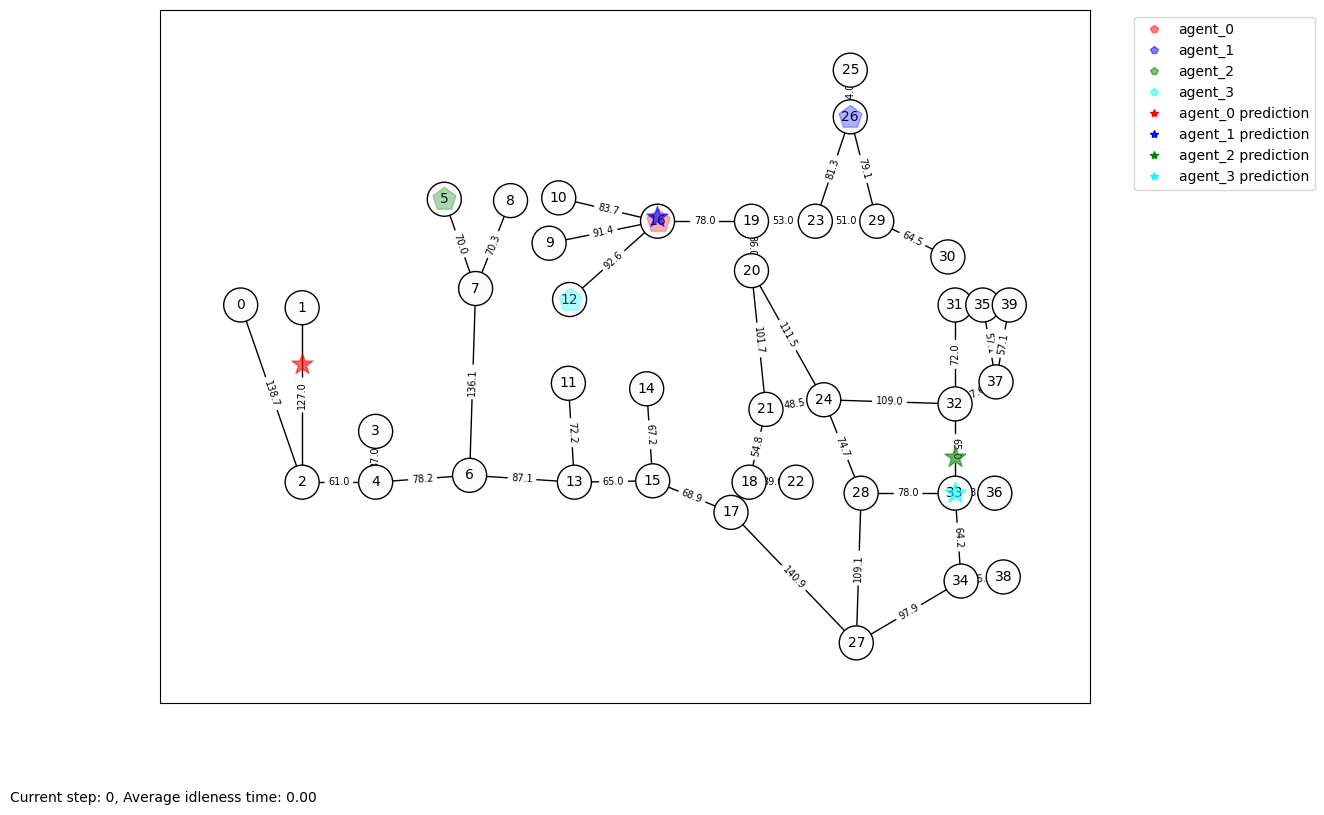

Step 0 - FPS: 2.16 (excluding render) - Reward Total: 228.59


In [6]:
main(arglist)